# TreeSHAP: Explaining XGBoost on an example dataset (diabetes prediction)

#### In previous section we used KernelSHAP which is a model agnostic method. In this section we will instead use TreeSHAP which is a modified version for explaining tree based models more efficiently. TreeSHAP also has a functionality to compute shap values while taking correlations among features into account which is not possible out of the box for kernelSHAP.

##### In this notebook we will go through an example where we try to predict diabetes status using some biomarkers and demographics information. We will use XGBoost model for the prediction task and later evaluate feature importance using TreeExplainer. 

#### The data used in this notebook was obtained from kaggle (https://www.kaggle.com/datasets/nanditapore/healthcare-diabetes/data).

In [1]:
"""
@author: Shreyash Garg, created Feb 2026 for IBMI spring school
Import all the relevant libraries
"""

import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from xgboost import XGBClassifier
from xgboost import plot_importance
import matplotlib.pyplot as plt
import shap
shap.initjs()

# 1. Load and prepare the dataset

In [2]:
# load diabetes dataset first
df=pd.read_csv("Healthcare-Diabetes.csv").set_index("Id")
# dropna values if there are any
df.dropna(inplace=True)

"""
ABOUT DATA 

This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases


Id: Unique identifier for each data entry.
Pregnancies: Number of times pregnant.
Glucose: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
BloodPressure: Diastolic blood pressure (mm Hg).
SkinThickness: Triceps skinfold thickness (mm).
Insulin: 2-Hour serum insulin (mu U/ml).
BMI: Body mass index (weight in kg / height in m^2).
DiabetesPedigreeFunction: Diabetes pedigree function, a genetic score of diabetes.
Age: Age in years.

Outcome: Binary classification indicating the presence (1) or absence (0) of diabetes.
"""
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Id,,,,,,,,,
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0
5,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
2764,2,75,64,24,55,29.7,0.370,33,0
2765,8,179,72,42,130,32.7,0.719,36,1
2766,6,85,78,0,0,31.2,0.382,42,0


# 2. Train and evaluate XGBoost model on the dataset

#### Here we use a nested 5-fold cross validation. The hyperparameters are tuned in the inner folds (n = 3).

In [3]:
# Load X y values
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

# Define the hyperparameter grid for XGBoost
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.1, 0.01, 0.001],
    'n_estimators': [50, 100, 200]
}

# Create the outer and inner cross-validation objects
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=999)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=999)

# Perform nested cross-validation
outer_scores = []

for train_idx, test_idx in outer_cv.split(X, y):
    X_train, X_test = X.iloc[train_idx,:], X.iloc[test_idx,:]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Perform hyperparameter tuning with inner cross-validation
    model = XGBClassifier(random_state=42)
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=inner_cv, scoring='balanced_accuracy')
    grid_search.fit(X_train, y_train)

    # Train the model with the best hyperparameters on the outer training fold
    best_model = grid_search.best_estimator_
    best_model.fit(X_train, y_train)

    # Evaluate the model on the outer validation fold
    y_pred = best_model.predict(X_test)
    score = balanced_accuracy_score(y_test, y_pred)
    outer_scores.append(score)
print("Out-of-sample test performances across folds : ",outer_scores)

Out-of-sample test performances across folds :  [0.9944903581267217, 0.9973821989528796, 0.9853528050896472, 0.9986225895316805, 0.9906046107003045]


# 3. Feature importance. Why use SHAP when we already have XGBoost's own explanations?
## 3.1 XGBoost's inbuilt XAI

#### XGBoost comes with explainability built in. One can use the plot_importance module from the xgboost library. It offers various ways of computing feature importance which can be passed as arguments to plot_importance function. 

#### Out of the box feature importance can be computed in one of the following ways:
##### 1. ‘weight’ - the number of times a feature is used to split the data across all trees.
##### 2. ‘gain’ - the average gain across all splits the feature is used in.
##### 3. ‘cover’ - the average coverage across all splits the feature is used in.
##### 4. ‘total_gain’ - the total gain across all splits the feature is used in.
##### 5. ‘total_cover’ - the total coverage across all splits the feature is used in.

### However if we use it we see a huge variability across the importance criteria (shown in 3 examples below). Whereas "weight criteria" ranks genetic predisposition (DiabetesPedigreeFunction) as the most important feature, 'gain' criteria ranks it as one of the least important feature.

## Example 1 "weight"

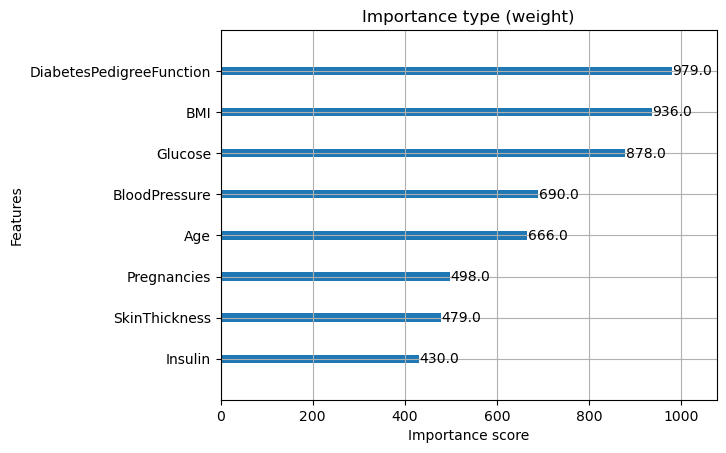

In [4]:
plot_importance(best_model, importance_type='weight')
plt.title("Importance type (weight)")
plt.show()

## Example 2: "cover"

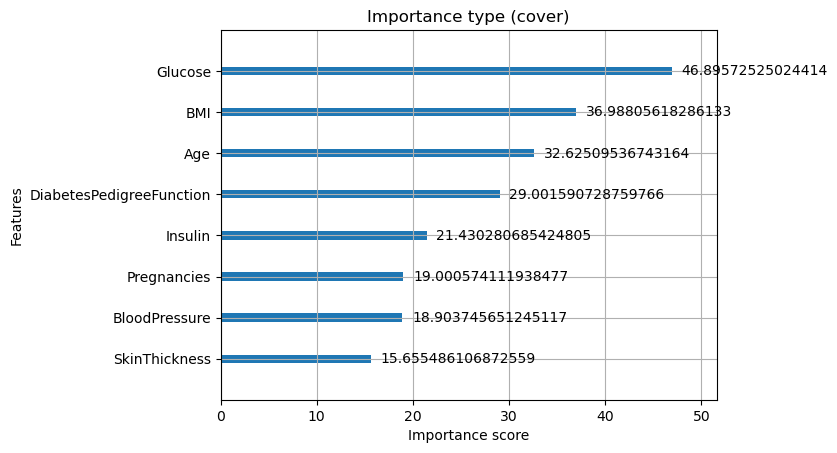

In [7]:
plot_importance(best_model, importance_type="cover")
plt.title('Importance type (cover)')
plt.show()

# Example 3: 'gain'

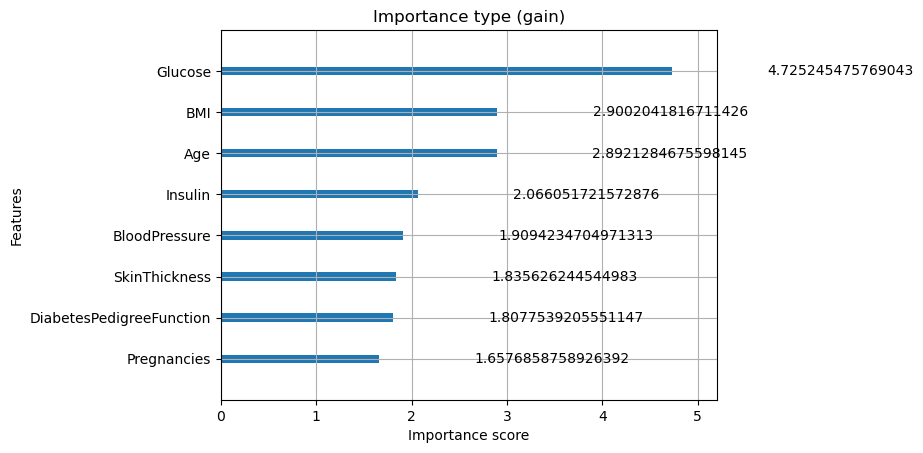

In [7]:
plot_importance(best_model, importance_type="gain")
plt.title('Importance type (gain)')
plt.show()

# Using TreeExplainer on our trained model
### As the explanations tend to diverge based on the criteria, we will now see how SHAP evaluates feature importance. For simplicity we will run the explainer on only the last trained model from our kfold run

In [8]:
# initialise the TreeExplainer
explainer = shap.TreeExplainer(best_model)

# Compute the shap values on the test set
shap_values = explainer.shap_values(X_test)
print("Shap values evaluated for {} sample with {} features in test set".format(X_test.shape[0],X_test.shape[1]))

Shap values evaluated for 553 sample with 8 features in test set


# 1. Various ways of visualising SHAP explanations

## 1.1 Visualising a single prediction

#### To visualise how prediction was made on a single instance in additive fashion one can use a Force plot. 
#### Starting from the base value / average model prediction (base value is the value that would be predicted if we did not know any features to the current output), each feature contribution is plotted in additive fashion with red bars indicating increase in final predicted (shown as arrow pointing towards right) value and blue bars indicating decrease in final predicted value (also shown as blue arrows pointing towards the left).

##### [Note] make sure to initialise javascript before running this i.e., shap.initjs()

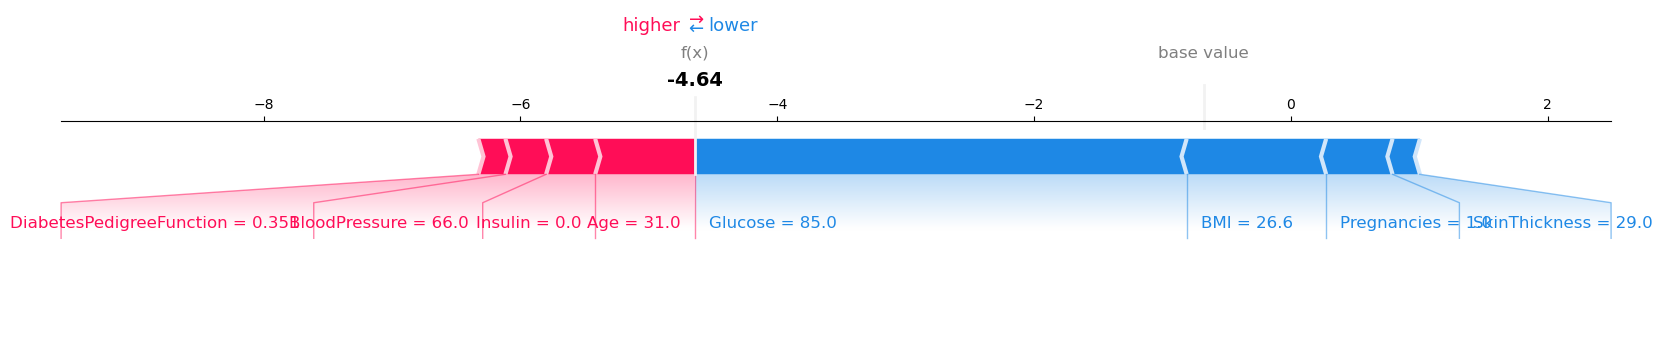

In [9]:
# change the following number to index different instance in the test set
x_i = 0

# Plot additive shap plot for a single prediction
shap.force_plot(explainer.expected_value, shap_values[x_i, :], X_test.iloc[x_i,:],matplotlib=True)


## 1.2 Visualing global importance (Summary plot (bar))

#### To visualise which features were more relevant across the whole evaluated instances we can use the summary plot feature from the shap library. The barplot shows the mean absolute value for each feature across the evaluated instances. The features are in asceding order of their mean absolute importance. For example the plot below shows that glucose was the most relevant feature in our dataset for prediction of diabetes.



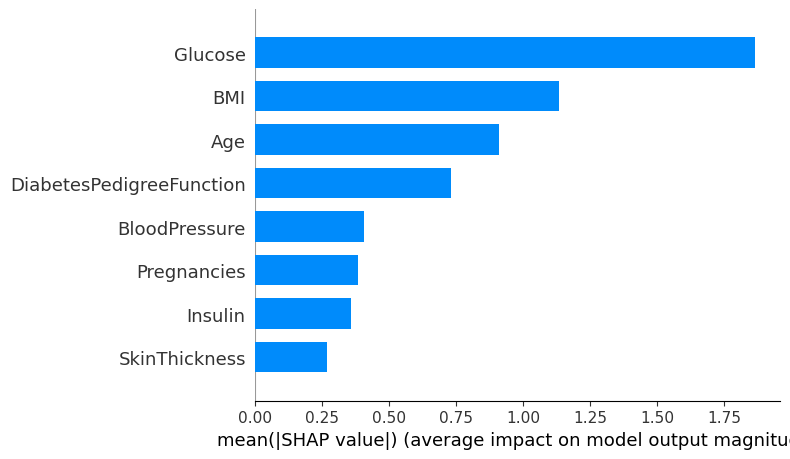

In [10]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

## 1.3 Visualing global importance (Summary plot (density scatter plot))

#### In the above plot we do not have any information on how the feature values themselves impacted model performance. Did higher glucose impact the model or whether lower blood glucose lead to prediction for diabetes?

#### A more informative form of summary plot is the density scatter plot. Here, again the feature are plotted in descending order of their absolute importance. However, the plot also shows the feature value (shown in blue-> red scale). 

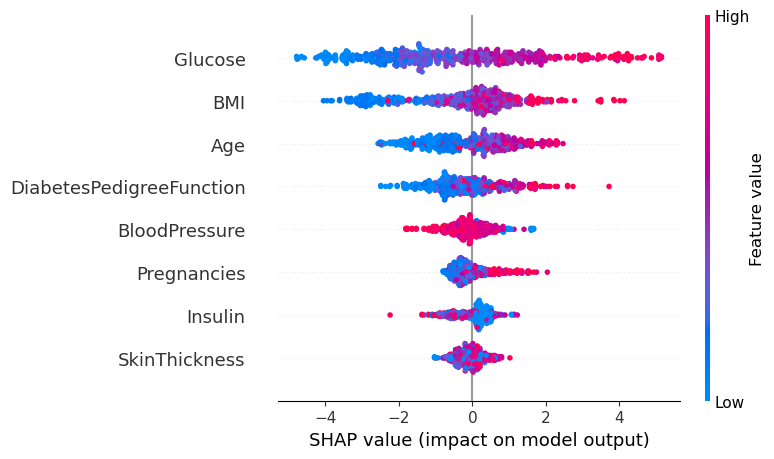

In [11]:
shap.summary_plot(shap_values, X_test)

## 1.4 Visualising model impact of a single feature (Dependence plots)
 
#### To visualise how the domain of feature (range of input value the feature takes) affected model prediction, one way would be to use dependence plots. 

#### For example in the plots below the X-axis represents range of values the feature takes. On the Y-axis are the corresponsing SHAP values. The points are color coded based on another variable in the dataset. For example in the first plot below, the points are color coded using Age.

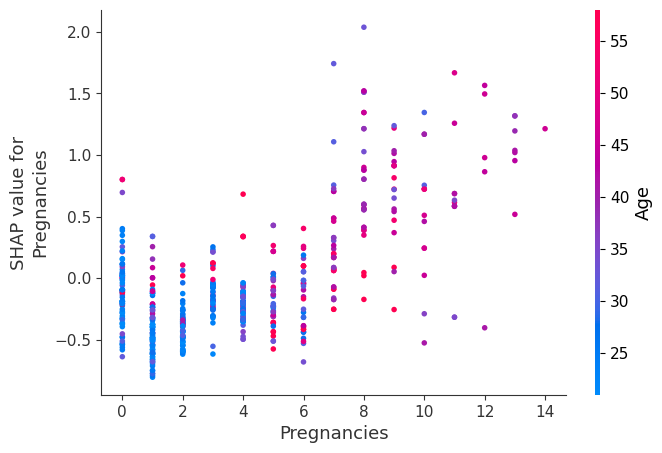

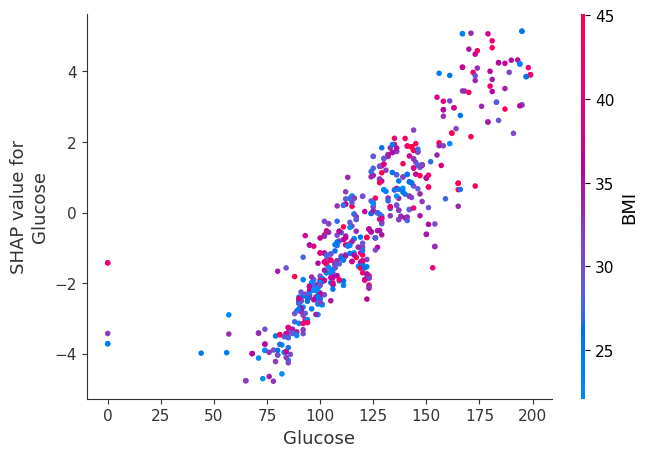

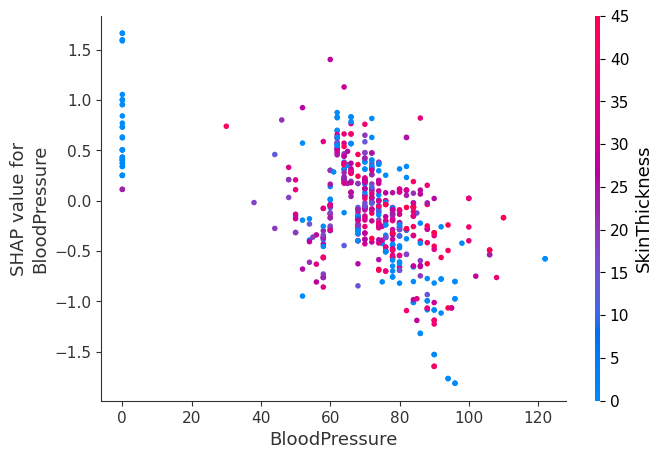

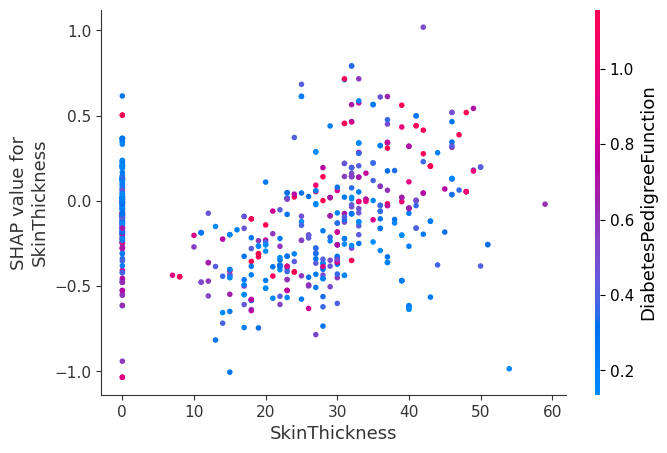

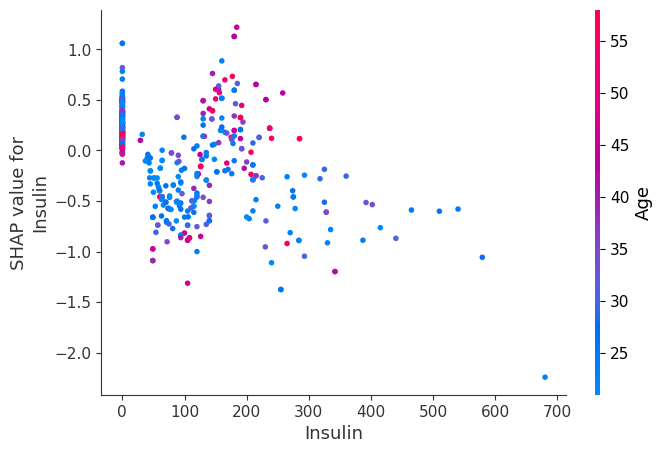

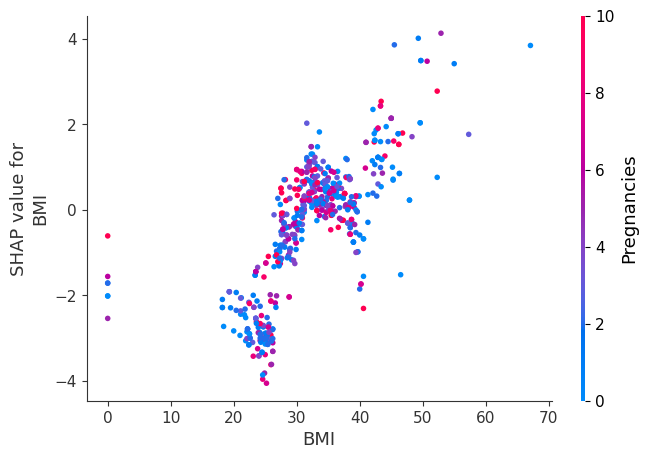

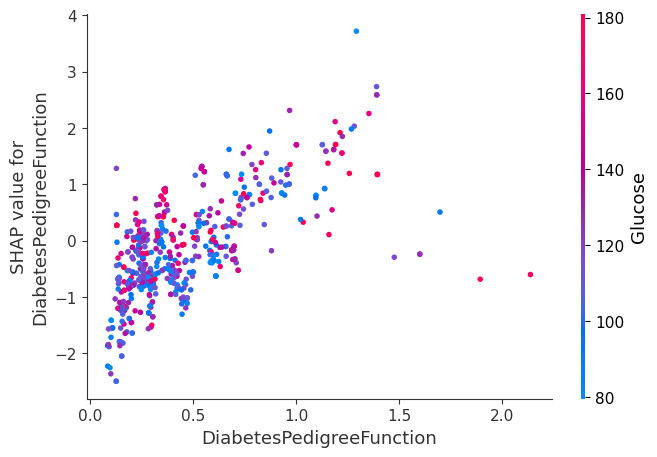

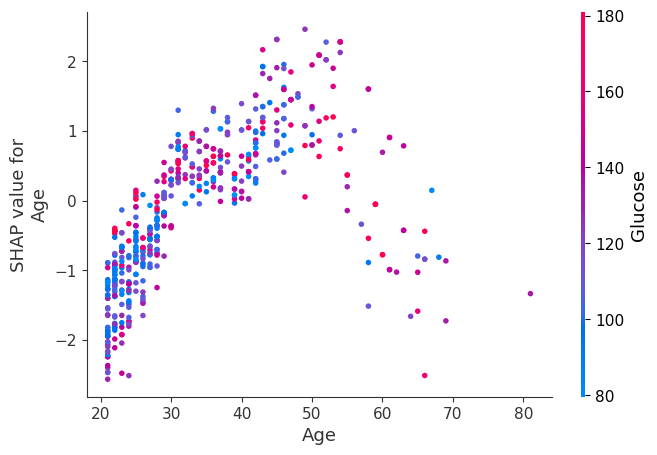

In [12]:
for name in X.columns:
    shap.dependence_plot(name, shap_values, X_test)